# C1 Smooth Goode Homolosine

*The classical Goode homolosine projection has a visible kink at latitude 40.736662°, because the sinusoidal and Mollweide regions are joined only with C0 continuity.

By inserting a simple equal-area trapezoidal transition region between the two projections, a C1-smooth Goode homolosine variant can be constructed.*

In [2]:
import mpmath as mp
mp.mp.dps=50
def theta_from_phi(phi):
    f=lambda th: 2*th+mp.sin(2*th)-mp.pi*mp.sin(phi)
    return mp.findroot(f, phi/2) # initial
def A_m(phi):
    th=theta_from_phi(phi)
    return (2*mp.sqrt(2)/mp.pi)*mp.cos(th)
def m_m(phi):
    th=theta_from_phi(phi)
    return -(2/mp.pi)*mp.tan(th)
def eq(phi2):
    th=theta_from_phi(phi2)
    s1=(2/mp.pi)*mp.tan(th)
    A2sq=1+s1**2-2*s1*mp.sin(phi2)
    return A2sq - A_m(phi2)**2
for deg in range(10,89,5):
    phi=mp.radians(deg)
    try:
        print(deg, eq(phi))
    except: pass
# find roots
roots=[]
for a in [i*mp.pi/180 for i in range(1,89)]:
    b=a+mp.pi/180
    try:
        if eq(a)*eq(b)<0:
            roots.append(mp.findroot(eq,(a,b)))
    except: pass
roots


10 0.18179721925428965612018245209340979999406511491234
15 0.17220662577319790874966192765942321966260945426631
20 0.15869336073920993672231142344979584495448270435996
25 0.14118432022607016939614568468844877799474936849422
30 0.11961109724861551837995255745752881624551772708963
35 0.093943962389257549536277258723993881247452685469812
40 0.064258801821228612984241065465109874949165170157737
45 0.030871938491066091253430939947911623669281748183315
50 -0.0053786378672961766526651949181142183422944394134987
55 -0.042516750661767305175080348057143641159847643547263
60 -0.075981167674710517979372563757848297178746223383234
65 -0.094898054329506891922004746000605094457651764250522
70 -0.071138687905250982564739206133668722479737061057542
75 0.079599511364576580659090381973628224216638721223974
80 0.68665636570824795965810498685876131937129562677321
85 4.0332036339060116379902919807838041997264282054305


[mpf('0.86000658652936492196781416619933002946636348231094747'),
 mpf('1.2776037852728873637319923287647477422460773640472847')]

In [3]:
for r in roots:
    th1=theta_from_phi(r)
    sinphi1=(2/mp.pi)*mp.tan(th1)
    if sinphi1<=1.0:
        th=th1
        phi1=mp.asin(sinphi1)
        print("phi2", mp.degrees(r), "\n","theta2", mp.degrees(th), "\n","phi1", mp.degrees(phi1), "\n","m", -mp.sin(phi1), "\n","A2", A_m(r))
        s1=mp.sin(phi1)
        print("A strip", mp.sqrt(1+s1*s1-2*s1*mp.sin(r)))
        phi2=r

phi2 49.274747761585044965239616066415380025998827829345 
 theta2 39.994507719295925094112239194415232828632363983441 
 phi1 32.28177336024240083033106451414967305463567993901 
 m -0.53408343199420536905726931832207241563807509019699 
 A2 0.68973778228510291998644626609477979131832252220724
A strip 0.68973778228510291998644626609477979131832252220724


In [4]:
A1 = mp.cos(phi1)      # sinusoidal side / lower parallel length factor
A2 = A_m(phi2)         # Mollweide side / upper parallel length factor

H_sinu = phi1

H_trap = 2 * (mp.sin(phi2) - mp.sin(phi1)) / (A1 + A2)

H_moll = mp.sqrt(2) - mp.sqrt(2) * mp.sin(theta_from_phi(phi2))
# equivalently, if y_moll = sqrt(2) * sin(theta2):
# H_moll = mp.sqrt(2) - y_moll

H_total_half = H_sinu + H_trap + H_moll
H_total = 2 * H_total_half

W_equator = 2 * mp.pi
aspect_ratio = W_equator / H_total

print("H_sinu", H_sinu)
print("H_trap", H_trap)
print("H_moll", H_moll)
print("H_total", H_total)
print("equatorial width", W_equator)
print("aspect ratio", aspect_ratio)

H_sinu 0.56342323351882344667279792628656191857753458170984
H_trap 0.2915162393533678379146711671662084797908152711403
H_moll 0.50527845942545575696183770414125178526254008973451
H_total 2.7204358645952940830986135951880443672617798851693
equatorial width 6.2831853071795864769252867665590057683943387987502
aspect ratio 2.3096244939831747055211860667930555071826920056198


In [5]:
print("phi1 : sinusoidal–trapezoidal transition latitude")
print("        also the latitude where the trapezoidal projection has exact scale")

print("phi2 : trapezoidal–Mollweide transition latitude")

print("theta2 : Mollweide auxiliary angle corresponding to phi2")

phi1 : sinusoidal–trapezoidal transition latitude
        also the latitude where the trapezoidal projection has exact scale
phi2 : trapezoidal–Mollweide transition latitude
theta2 : Mollweide auxiliary angle corresponding to phi2


In [6]:
mp.degrees(th),mp.degrees(phi1),mp.degrees(phi2)

(mpf('39.994507719295925094112239194415232828632363983440932'),
 mpf('32.2817733602424008303310645141496730546356799390104'),
 mpf('49.274747761585044965239616066415380025998827829345243'))

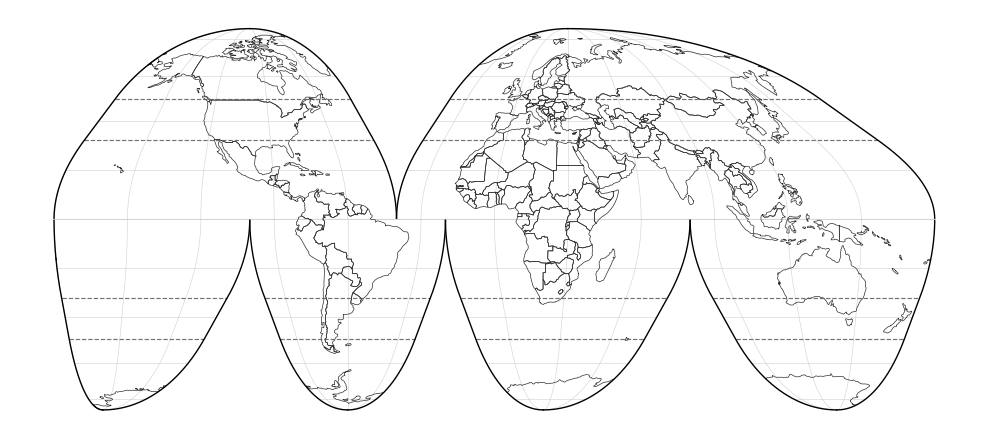

Saved PNG: ./interrupted_park_goode_no_equator_split_fixed.png
Saved PDF: ./interrupted_park_goode_no_equator_split_fixed.pdf


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from scipy.optimize import brentq
from pathlib import Path

# ============================================================
# Interrupted Park-Goode 3-zone map
# Fixes:
# 1) Coast/country linework uses one fixed color, so countries crossing equator
#    are not visually split into different colors.
# 2) Equator is NOT drawn as a thick interruption boundary.
# 3) Interruption boundaries stop just short of the equator.
# ============================================================

# -----------------------------
# Projection constants
# -----------------------------
phi1 = np.deg2rad(32.2817733602)
phi2 = np.deg2rad(49.2747477615)

m = -np.sin(phi1)
A1 = np.cos(phi1)
b = A1 - m * phi1

def moll_theta_scalar(phi):
    if abs(abs(phi) - np.pi / 2) < 1e-12:
        return np.sign(phi) * np.pi / 2
    if abs(phi) < 1e-12:
        return 0.0
    return brentq(lambda th: 2 * th + np.sin(2 * th) - np.pi * np.sin(phi),
                  -np.pi / 2, np.pi / 2)

def moll_theta(phi):
    arr = np.asarray(phi)
    if arr.ndim == 0:
        return moll_theta_scalar(float(arr))
    return np.array([moll_theta_scalar(float(p)) for p in arr.ravel()]).reshape(arr.shape)

def middle_Y_abs(phi_abs):
    return (-b + np.sqrt(A1**2 + 2 * m * (np.sin(phi_abs) - np.sin(phi1)))) / m

Y2 = middle_Y_abs(phi2)
moll_shift = Y2 - np.sqrt(2) * np.sin(moll_theta(phi2))
Ymax = np.sqrt(2) + moll_shift

def A_Y_from_lat(lat_deg):
    phi = np.deg2rad(np.clip(lat_deg, -90, 90))
    s = np.sign(phi)
    a = abs(phi)

    if a <= phi1:
        return np.cos(a), s * a
    if a <= phi2:
        Y = middle_Y_abs(a)
        return m * Y + b, s * Y

    th = moll_theta(a)
    A = (2 * np.sqrt(2) / np.pi) * np.cos(th)
    Y = np.sqrt(2) * np.sin(th) + moll_shift
    return A, s * Y

# -----------------------------
# Interrupted lobes
# -----------------------------
NORTH = [(-180, -40, -100), (-40, 180, 30)]
SOUTH = [(-180, -100, -160), (-100, -20, -60), (-20, 80, 20), (80, 180, 140)]
EQUATOR = (-180, 180, 0)

def norm_lon(lon):
    return ((lon + 180) % 360) - 180

def rel_lon(lon, lon0):
    return ((lon - lon0 + 180) % 360) - 180

def choose_lobe(lon, lat):
    lon = norm_lon(lon)
    if abs(lat) < 1e-10:
        lo, hi, lon0 = EQUATOR
        return ("E", 0, lo, hi, lon0)

    lobes = NORTH if lat > 0 else SOUTH
    hemi = "N" if lat > 0 else "S"

    for i, (lo, hi, lon0) in enumerate(lobes):
        if lo <= lon <= hi:
            return (hemi, i, lo, hi, lon0)

    # fallback for longitude edge cases
    lo, hi, lon0 = lobes[0]
    return (hemi, 0, lo, hi, lon0)

def project(lon, lat, forced_lobe=None):
    lobe = forced_lobe if forced_lobe is not None else choose_lobe(lon, lat)
    if lobe is None:
        return None

    hemi, i, lo, hi, lon0 = lobe
    A, Y = A_Y_from_lat(lat)
    x = np.deg2rad(rel_lon(norm_lon(lon), lon0)) * A + np.deg2rad(lon0)
    return x, Y, (hemi, i)

# -----------------------------
# Densify and split only for actual lobe jumps
# -----------------------------
def densify(p0, p1, step=0.30):
    lon0, lat0 = p0
    lon1, lat1 = p1

    dlon = lon1 - lon0
    if abs(dlon) > 180:
        lon1 -= 360 * np.sign(dlon)

    n = max(1, int(np.ceil(max(abs(lon1 - lon0), abs(lat1 - lat0)) / step)))
    return [(norm_lon(lon0 + (lon1 - lon0) * k / n),
             lat0 + (lat1 - lat0) * k / n) for k in range(n)]

def polyline_segments(points):
    segs, cur, prev_key = [], [], None

    for lon, lat in points:
        pr = project(lon, lat)
        if pr is None:
            if len(cur) >= 2:
                segs.append(np.array(cur))
            cur, prev_key = [], None
            continue

        x, y, key = pr

        # Split if lobe key changes. This is geometrically necessary,
        # but visual color will remain fixed later.
        if prev_key is not None and key != prev_key:
            if len(cur) >= 2:
                segs.append(np.array(cur))
            cur = []

        cur.append((x, y))
        prev_key = key

    if len(cur) >= 2:
        segs.append(np.array(cur))

    return segs

def ring_segments(coords):
    coords = list(coords)
    dense = []
    for a, bpt in zip(coords[:-1], coords[1:]):
        dense.extend(densify(a, bpt))
    dense.append(coords[-1])
    return polyline_segments(dense)

def geom_segments(geom):
    segs = []
    if isinstance(geom, Polygon):
        segs.extend(ring_segments(geom.exterior.coords))
        for interior in geom.interiors:
            segs.extend(ring_segments(interior.coords))
    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            segs.extend(geom_segments(poly))
    return segs

# -----------------------------
# 4) Load world polygons
# -----------------------------
#shp_path = "/opt/pyvenv/lib/python3.13/site-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp"
#world = gpd.read_file(shp_path)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_segments = []
for geom in world.geometry:
    world_segments.extend(geom_segments(geom))


# -----------------------------
# Graticule
# -----------------------------
graticule_segments = []
for lat in range(-80, 81, 20):
    lons = np.linspace(-180, 180, 1201)
    if lat == 0:
        forced = ("E", 0, *EQUATOR)
        pts = []
        for lon in lons:
            x, y, _ = project(lon, lat, forced_lobe=forced)
            pts.append((x, y))
        graticule_segments.append(np.array(pts))
    else:
        graticule_segments.extend(polyline_segments([(lon, lat) for lon in lons]))

for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 1201)
    graticule_segments.extend(polyline_segments([(lon, lat) for lat in lats]))

# transition guides
guide_segments = []
for lat in [np.rad2deg(phi1), -np.rad2deg(phi1), np.rad2deg(phi2), -np.rad2deg(phi2)]:
    guide_segments.extend(polyline_segments([(lon, lat) for lon in np.linspace(-180, 180, 1201)]))

# -----------------------------
# Explicit lobe outlines excluding equator
# -----------------------------
def lobe_boundary(hemi, i, lo, hi, lon0, eps=0.45):
    # eps in degrees, so thick boundaries do not touch/paint over equator
    lat_min, lat_max = (eps, 90) if hemi == "N" else (-90, -eps)
    forced = (hemi, i, lo, hi, lon0)
    pieces = []

    # pole-side edge
    lat_edge = lat_max if hemi == "N" else lat_min
    pts = []
    for lon in np.linspace(lo, hi, 600):
        x, y, _ = project(lon, lat_edge, forced_lobe=forced)
        pts.append((x, y))
    pieces.append(np.array(pts))

    # cut edges
    for lon in [lo, hi]:
        pts = []
        for lat in np.linspace(lat_min, lat_max, 600):
            x, y, _ = project(lon, lat, forced_lobe=forced)
            pts.append((x, y))
        pieces.append(np.array(pts))

    return pieces

outline_segments = []
for i, (lo, hi, lon0) in enumerate(NORTH):
    outline_segments.extend(lobe_boundary("N", i, lo, hi, lon0))
for i, (lo, hi, lon0) in enumerate(SOUTH):
    outline_segments.extend(lobe_boundary("S", i, lo, hi, lon0))

# -----------------------------
# Plot with fixed colors
# -----------------------------
fig, ax = plt.subplots(figsize=(12.5, 6.8))

# graticule: all light gray, including equator (not thick)
for arr in graticule_segments:
    ax.plot(arr[:, 0], arr[:, 1], color="0.78", linewidth=0.45, alpha=0.75, zorder=1)

# country/coast lines: fixed dark color, never auto-cycled
for arr in world_segments:
    ax.plot(arr[:, 0], arr[:, 1], color="0.18", linewidth=0.50, zorder=2)

# transition latitude guide: dashed dark gray
for arr in guide_segments:
    ax.plot(arr[:, 0], arr[:, 1], color="0.35", linewidth=0.85, linestyle="--", alpha=0.85, zorder=3)

# lobe boundaries: thick black, not touching equator
for arr in outline_segments:
    ax.plot(arr[:, 0], arr[:, 1], color="black", linewidth=1, zorder=10)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")
'''ax.set_title(
    "Interrupted Park–Goode 3-zone equal-area projection\n"
    "fixed coastline color; equator not used as interruption boundary"
)'''

png_path = "./interrupted_park_goode_no_equator_split_fixed.png"
pdf_path = "./interrupted_park_goode_no_equator_split_fixed.pdf"
fig.savefig(png_path, dpi=240, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

In [8]:
# Note:
# All formal solutions are evaluated below, including cases where some
# intermediate angles become imaginary, which may lead to errors.


def print_all_solutions(roots):
    # Note:
    # All formal solutions are evaluated below, including cases where some
    # intermediate angles become imaginary, which may lead to errors.

    for r in roots:
        th = theta_from_phi(r)
        phi1 = mp.asin((2/mp.pi) * mp.tan(th))

        print(
            "phi2", mp.degrees(r),
            "theta2", th,
            "phi1", mp.degrees(phi1),
            "m", -mp.sin(phi1),
            "A2", A_m(r)
        )

        s1 = mp.sin(phi1)

        print(
            "A strip",
            mp.sqrt(1 + s1*s1 - 2*s1*mp.sin(r))
        )

print_all_solutions(roots)


phi2 49.274747761585044965239616066415380025998827829345 theta2 0.69803584241600197131657820731038170999369089286723 phi1 32.28177336024240083033106451414967305463567993901 m -0.53408343199420536905726931832207241563807509019699 A2 0.68973778228510291998644626609477979131832252220724
A strip 0.68973778228510291998644626609477979131832252220724
phi2 73.201304786074724393076370891678685892347096187418 theta2 1.0988267298855639815410250159029646915556875718293 phi1 (90.0 - 39.498521517044178917430890627165544491644273459863j) m (-1.247182918822684976589261446431790728197210554301 - 3.7663344190497772189595493913647602166987942631519e-52j) A2 0.40932110278263030612852171838714717750509867818108
A strip (0.40932110278263030612852171838714717750509867818107 + 2.6670938382556059910013368990350919983994339097302e-52j)


# Goode Homolosine Projection

In [10]:
import mpmath as mp

mp.mp.dps=50

def equations(ph, th):

    return [2*th+mp.sin(2*th)-mp.pi*mp.sin(ph), mp.pi*mp.cos(ph)/(2*mp.sqrt(2)*mp.cos(th))-1]

sol= mp.findroot(lambda ph, th: (2*th+mp.sin(2*th)-mp.pi*mp.sin(ph), mp.pi*mp.cos(ph)/(2*mp.sqrt(2)*mp.cos(th))-1), (0.71, 0.57))

ph=sol[0] # ph is the transition latitude in radians; ph*180/mp.pi is the transition latitude in degrees

th=sol[1] # th is auxiliary angle for Mollweide projection in radians

H=2*(ph + mp.sqrt(2)*(1-mp.sin(th)))/mp.pi
print("transition phi", mp.degrees(ph))
print("transition theta",  mp.degrees(th))
print("aspect ratio:", str(2/H)[0:200])

transition phi 40.736662189751368785811928076700219402966767058749
transition theta 32.689275014625620698342457733836465480410633344099
aspect ratio: 2.3076020984223785433801708051306339085585169586486


# Comparison between the Classical Goode Homolosine and the C1 Smooth Goode Homolosine

*The two projections have almost identical aspect ratios. This suggests that the C1 Smooth Goode Homolosine can serve as a direct replacement for the classical Goode homolosine in most statistical and thematic mapping applications, while preserving nearly the same overall visual proportions.*

# C2 Smooth Goode Homolosine

*C1-smooth Goode homolosine projections are simple and practical, but still possess an aesthetic limitation in that the curvature transition is not sufficiently smooth.

To address this issue, a C2-smooth Goode homolosine satisfying convexity conditions is needed.*